In [1]:
import os
import time
import json
import argparse
from dataclasses import asdict
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import yaml

In [6]:
os.chdir('..')

In [18]:
## Get all the training results
res_dir = 'Results/summary/a13_multi_results.csv'
results_df = pd.read_csv(res_dir)
mean_errors = results_df.groupby(['model','sensor_count'])['error_u'].mean()
std_errors = results_df.groupby(['model','sensor_count'])['error_u'].std()
mean_nn = mean_errors['NN']
std_nn = std_errors['NN']
mean_linear = mean_errors['PINN']
std_linear = std_errors['PINN']

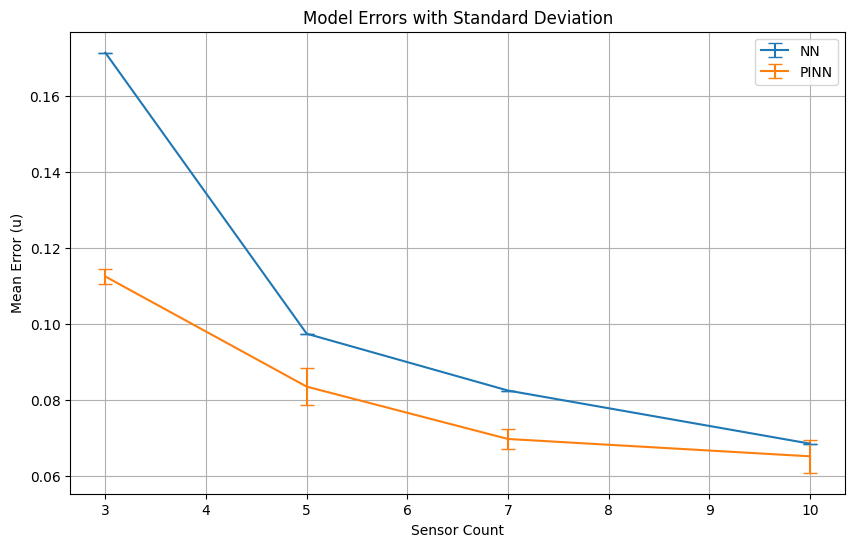

In [19]:
# create a plot of the model errors with standard deviation as error bars
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for model in mean_errors.index.levels[0]:
    plt.errorbar(mean_errors[model].index, mean_errors[model], yerr=std_errors[model], label=model, capsize=5)
# plt.errorbar(mean_nn.index, mean_nn, yerr=std_nn, label='NN', capsize=5, fmt='o--', color='black')
plt.xlabel('Sensor Count')
plt.ylabel('Mean Error (u)')
plt.title('Model Errors with Standard Deviation')
plt.legend()
plt.grid()
plt.show()

In [21]:
## Get all the training results
res_dir = 'Results_FD/summary/a13_multi_results.csv'
results_df = pd.read_csv(res_dir)
results_df = results_df[results_df['sensor_count']<11]
mean_errors = results_df.groupby(['fd_name','sensor_count'])['error_u'].mean()
std_errors = results_df.groupby(['fd_name','sensor_count'])['error_u'].std()

In [22]:
mean_errors

fd_name     sensor_count
exp         3               0.120031
            5               0.100527
            7               0.101066
            10              0.110622
linear      3               0.118317
            5               0.098590
            7               0.069792
            10              0.065230
log         3               0.106413
            5               0.093588
            7               0.083493
            10              0.090045
power       3               0.114869
            5               0.098074
            7               0.092448
            10              0.096493
triangular  3               0.129047
            5               0.115195
            7               0.126620
            10              0.126672
Name: error_u, dtype: float64

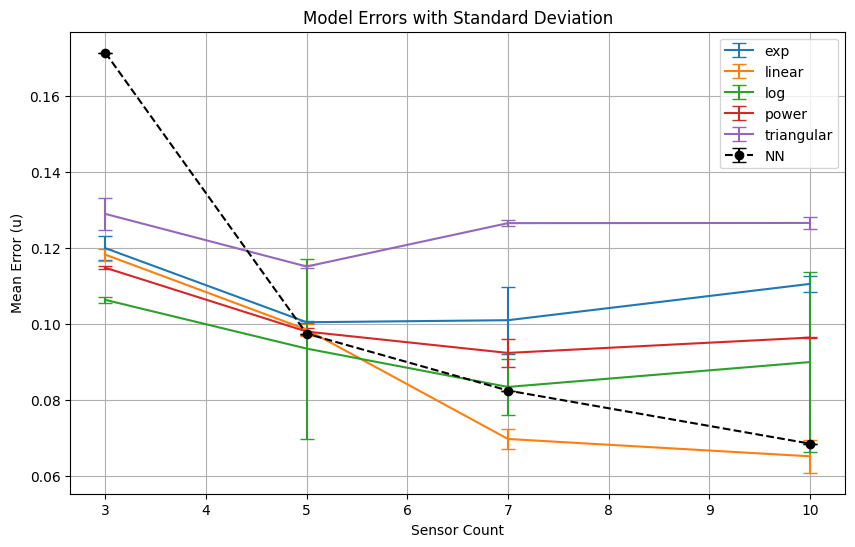

In [23]:
# create a plot of the model errors with standard deviation as error bars
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for model in mean_errors.index.levels[0]:
    plt.errorbar(mean_errors[model].index, mean_errors[model], yerr=std_errors[model], label=model, capsize=5)
plt.errorbar(mean_nn.index, mean_nn, yerr=std_nn, label='NN', capsize=5, fmt='o--', color='black')
# plt.errorbar(mean_linear.index, mean_linear, yerr=std_linear, label='Linear', capsize=5, fmt='s--', color='blue')
plt.xlabel('Sensor Count')
plt.ylabel('Mean Error (u)')
plt.title('Model Errors with Standard Deviation')
plt.legend()
plt.grid()
plt.show()